In [30]:
import torch
from pprint import pprint

info = torch.load("eval_result/tests_cfg_1025/default/results.pt")
print(info.keys())          # dict_keys(['per_task', 'per_group', 'overall'])
pprint(info["overall"])  
for i in range(10):
    list=(info["per_task"][i]['metrics']['successes']) 
    pprint(sum(list)/len(list))



dict_keys(['per_task', 'per_group', 'overall'])
{'avg_max_reward': 0.18,
 'avg_sum_reward': 0.18,
 'eval_ep_s': 9.715211099386215,
 'eval_s': 1943.0422196388245,
 'n_episodes': 200,
 'pc_success': 18.0,
 'video_paths': []}
0.0
0.0
0.35
0.05
0.0
0.5
0.05
0.05
0.4
0.4


In [6]:
import torch
from pprint import pprint

info = torch.load("eval_result/tests_cfg_1025_chunksize50/h10_naive/results.pt")
# print(info.keys())          # dict_keys(['per_task', 'per_group', 'overall'])
print(info["overall"]['pc_success'],"\n")  
for i in range(10):
    list=(info["per_task"][i]['metrics']['successes']) 
    pprint(sum(list)/len(list))



13.5 

0.0
0.05
0.4
0.1
0.0
0.4
0.05
0.0
0.15
0.2


In [7]:
import torch
from pprint import pprint

info = torch.load("eval_result/tests_cfg_1025_chunksize50/h10_naive_nulla/results.pt")
# print(info.keys())          # dict_keys(['per_task', 'per_group', 'overall'])
print(info["overall"]['pc_success'],"\n")  
for i in range(10):
    list=(info["per_task"][i]['metrics']['successes']) 
    pprint(sum(list)/len(list))



21.5 

0.1
0.35
0.5
0.15
0.0
0.65
0.1
0.05
0.0
0.25


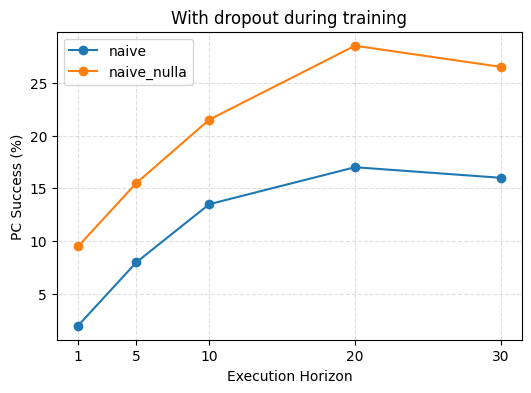

In [9]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

# Root folder where cfg_test_runner saved the results
RESULTS_ROOT = Path("eval_result/tests_cfg_1025_chunksize50")

# Horizons you evaluated (must match cfg_test_runner)
execution_horizons = [1, 5, 10, 20, 30]

# Map strategy labels to the suffixes used in the folder names
strategies = {
    "naive": "naive",
    "naive_nulla": "naive_nulla",
}

pc_success = {name: [] for name in strategies}

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for label, suffix in strategies.items():
        run_dir = RESULTS_ROOT / f"{prefix}_{suffix}"
        results_path = run_dir / "results.pt"
        if not results_path.exists():
            raise FileNotFoundError(f"Missing {results_path}; make sure the eval ran for this setting.")
        info = torch.load(results_path)
        pc_success[label].append(info["overall"]["pc_success"])

plt.figure(figsize=(6, 4))
for label, values in pc_success.items():
    plt.plot(execution_horizons, values, marker="o", label=label)

plt.xlabel("Execution Horizon")
plt.ylabel("PC Success (%)")
plt.title("With dropout during training")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


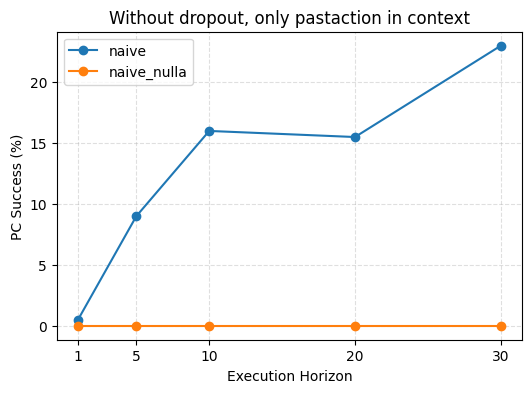

In [10]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

# Root folder where cfg_test_runner saved the results
RESULTS_ROOT = Path("eval_result/tests_nocfg_chunksize50")

# Horizons you evaluated (must match cfg_test_runner)
execution_horizons = [1, 5, 10, 20, 30]

# Map strategy labels to the suffixes used in the folder names
strategies = {
    "naive": "naive",
    "naive_nulla": "naive_nulla",
}

pc_success = {name: [] for name in strategies}

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for label, suffix in strategies.items():
        run_dir = RESULTS_ROOT / f"{prefix}_{suffix}"
        results_path = run_dir / "results.pt"
        if not results_path.exists():
            raise FileNotFoundError(f"Missing {results_path}; make sure the eval ran for this setting.")
        info = torch.load(results_path)
        pc_success[label].append(info["overall"]["pc_success"])

plt.figure(figsize=(6, 4))
for label, values in pc_success.items():
    plt.plot(execution_horizons, values, marker="o", label=label)

plt.xlabel("Execution Horizon")
plt.ylabel("PC Success (%)")
plt.title("Without dropout, only pastaction in context")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


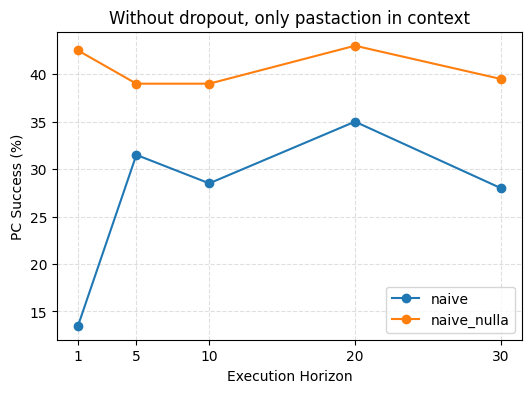

In [1]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

# Root folder where cfg_test_runner saved the results
RESULTS_ROOT = Path("eval_result/cfg_1030_drpastactions_40k")

# Horizons you evaluated (must match cfg_test_runner)
execution_horizons = [1, 5, 10, 20, 30]

# Map strategy labels to the suffixes used in the folder names
strategies = {
    "naive": "naive",
    "naive_nulla": "naive_nulla",
}

pc_success = {name: [] for name in strategies}

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for label, suffix in strategies.items():
        run_dir = RESULTS_ROOT / f"{prefix}_{suffix}"
        results_path = run_dir / "results.pt"
        if not results_path.exists():
            raise FileNotFoundError(f"Missing {results_path}; make sure the eval ran for this setting.")
        info = torch.load(results_path)
        pc_success[label].append(info["overall"]["pc_success"])

plt.figure(figsize=(6, 4))
for label, values in pc_success.items():
    plt.plot(execution_horizons, values, marker="o", label=label)

plt.xlabel("Execution Horizon")
plt.ylabel("PC Success (%)")
plt.title("Without dropout, only pastaction in context")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


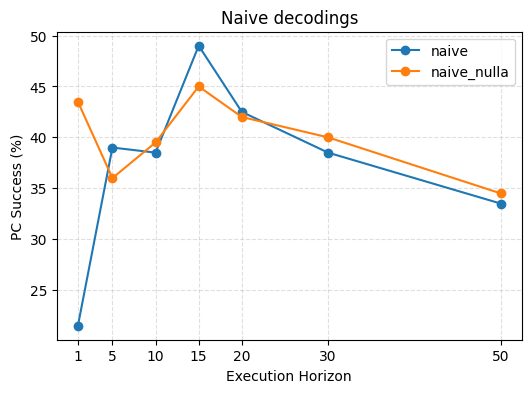

In [5]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

# Root folder where cfg_test_runner saved the results
RESULTS_ROOT = Path("eval_result/cfg_1030_drpastactions_40k_1102")

# Horizons you evaluated (must match cfg_test_runner)
execution_horizons = [1, 5, 10, 15, 20, 30,50]

# Map strategy labels to the suffixes used in the folder names
strategies = {
    "naive": "naive",
    "naive_nulla": "naive_nulla",
}

pc_success = {name: [] for name in strategies}

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for label, suffix in strategies.items():
        run_dir = RESULTS_ROOT / f"{prefix}_{suffix}"
        results_path = run_dir / "results.pt"
        if not results_path.exists():
            raise FileNotFoundError(f"Missing {results_path}; make sure the eval ran for this setting.")
        info = torch.load(results_path)
        pc_success[label].append(info["overall"]["pc_success"])

plt.figure(figsize=(6, 4))
for label, values in pc_success.items():
    plt.plot(execution_horizons, values, marker="o", label=label)

plt.xlabel("Execution Horizon")
plt.ylabel("PC Success (%)")
plt.title("Naive decodings")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


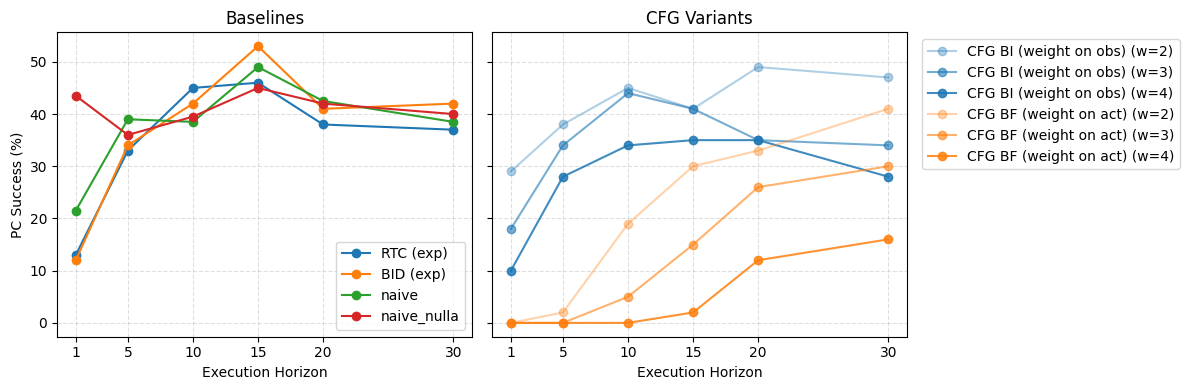

In [19]:
from pathlib import Path
from collections import defaultdict

import torch
import matplotlib.pyplot as plt
import numpy as np

# Root folder produced by cfg_test_runner.py
RESULTS_ROOT = Path("eval_result/cfg_1030_drpastactions_40k_1102")

# Horizons evaluated in cfg_test_runner
execution_horizons = [1, 5, 10, 15, 20, 30]

# --- 1) Load single-strategy runs (RTC / BID) -------------------------------
single_strategies = {
    "RTC (exp)": "rtc_exp",
    "BID (exp)": "bid_exp",
    "naive": "naive",
    "naive_nulla": "naive_nulla",
}

single_scores = defaultdict(list)

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for label, suffix in single_strategies.items():
        results_path = RESULTS_ROOT / f"{prefix}_{suffix}" / "results.pt"
        info = torch.load(results_path)
        single_scores[label].append(info["overall"]["pc_success"])

# --- 2) Load CFG groups (three families) -----------------------------------
cfg_groups = {
    "CFG BI (weight on obs)": "cfg_BI_wo",
    # "CFG BI (weight on act)": "cfg_BI_wa",
    "CFG BF (weight on act)": "cfg_BF_wa",
}
weight_values = [2, 3, 4]
alpha_map = {w: np.linspace(0.35, 0.85, len(weight_values))[i] for i, w in enumerate(weight_values)}

cfg_scores = {
    group_label: {w: [] for w in weight_values} for group_label in cfg_groups
}

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for group_label, suffix_base in cfg_groups.items():
        for w in weight_values:
            results_path = RESULTS_ROOT / f"{prefix}_{suffix_base}_{w}" / "results.pt"
            info = torch.load(results_path)
            cfg_scores[group_label][w].append(info["overall"]["pc_success"])

# --- 3) Plot ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# (a) RTC / BID comparison
plt.subplot(1, 2, 1)
for label, scores in single_scores.items():
    plt.plot(execution_horizons, scores, marker="o", label=label)
plt.xlabel("Execution Horizon")
plt.ylabel("PC Success (%)")
plt.title("Baselines")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

# (b) CFG variants grouped, fading alpha for larger w
plt.subplot(1, 2, 2)
color_map = plt.get_cmap("tab10")
for idx, (group_label, per_weight) in enumerate(cfg_scores.items()):
    base_color = color_map(idx)
    for w, scores in per_weight.items():
        plt.plot(
            execution_horizons,
            scores,
            marker="o",
            label=f"{group_label} (w={w})",
            color=base_color,
            alpha=alpha_map[w],
        )
plt.xlabel("Execution Horizon")
# plt.ylabel("PC Success (%)")
plt.title("CFG Variants")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


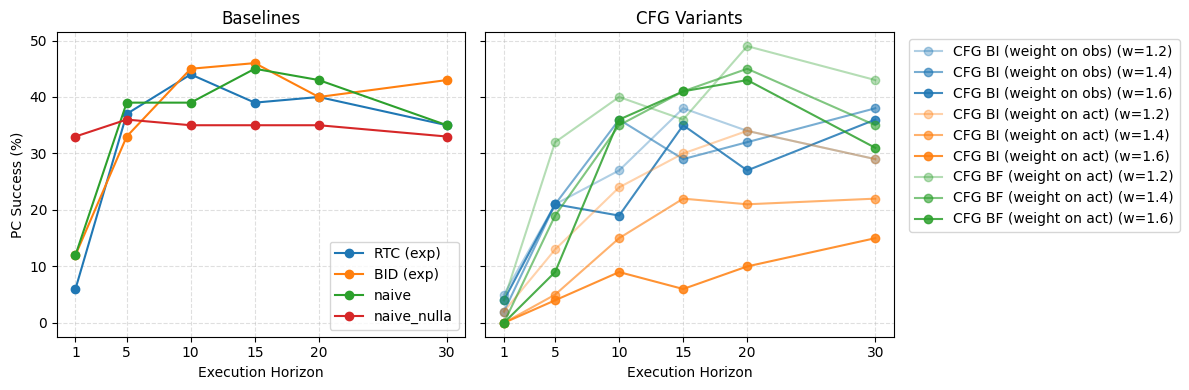

In [3]:
from pathlib import Path
from collections import defaultdict

import torch
import matplotlib.pyplot as plt
import numpy as np

# Root folder produced by cfg_test_runner.py
RESULTS_ROOT = Path("eval_result/cfg_1104_20pastactions")

# Horizons evaluated in cfg_test_runner
execution_horizons = [1, 5, 10, 15, 20, 30]

# --- 1) Load single-strategy runs (RTC / BID) -------------------------------
single_strategies = {
    "RTC (exp)": "rtc_exp",
    "BID (exp)": "bid_exp",
    "naive": "naive",
    "naive_nulla": "naive_nulla",
}

single_scores = defaultdict(list)

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for label, suffix in single_strategies.items():
        results_path = RESULTS_ROOT / f"{prefix}_{suffix}" / "results.pt"
        info = torch.load(results_path)
        single_scores[label].append(info["overall"]["pc_success"])

# --- 2) Load CFG groups (three families) -----------------------------------
cfg_groups = {
    "CFG BI (weight on obs)": "cfg_BI_wo",
    "CFG BI (weight on act)": "cfg_BI_wa",
    "CFG BF (weight on act)": "cfg_BF_wa",
}
weight_values = [1.2, 1.4, 1.6]
alpha_map = {w: np.linspace(0.35, 0.85, len(weight_values))[i] for i, w in enumerate(weight_values)}

cfg_scores = {
    group_label: {w: [] for w in weight_values} for group_label in cfg_groups
}

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for group_label, suffix_base in cfg_groups.items():
        for w in weight_values:
            results_path = RESULTS_ROOT / f"{prefix}_{suffix_base}_{w}" / "results.pt"
            info = torch.load(results_path)
            cfg_scores[group_label][w].append(info["overall"]["pc_success"])

# --- 3) Plot ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# (a) RTC / BID comparison
plt.subplot(1, 2, 1)
for label, scores in single_scores.items():
    plt.plot(execution_horizons, scores, marker="o", label=label)
plt.xlabel("Execution Horizon")
plt.ylabel("PC Success (%)")
plt.title("Baselines")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

# (b) CFG variants grouped, fading alpha for larger w
plt.subplot(1, 2, 2)
color_map = plt.get_cmap("tab10")
for idx, (group_label, per_weight) in enumerate(cfg_scores.items()):
    base_color = color_map(idx)
    for w, scores in per_weight.items():
        plt.plot(
            execution_horizons,
            scores,
            marker="o",
            label=f"{group_label} (w={w})",
            color=base_color,
            alpha=alpha_map[w],
        )
plt.xlabel("Execution Horizon")
# plt.ylabel("PC Success (%)")
plt.title("CFG Variants")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


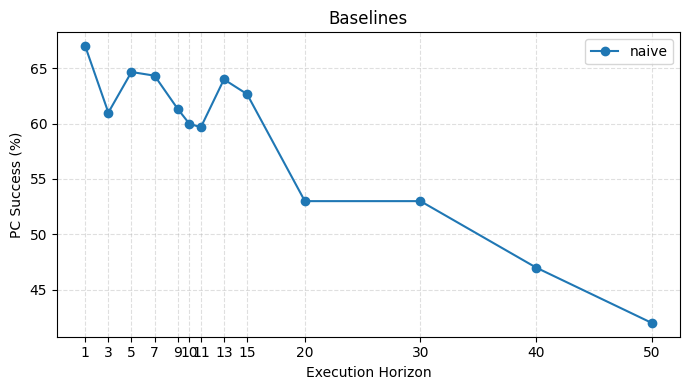

In [15]:
from pathlib import Path
from collections import defaultdict

import torch
import matplotlib.pyplot as plt
import numpy as np

# Root folder produced by cfg_test_runner.py
RESULTS_ROOT = Path("eval_result/default_smolvla1109_25k")

# Horizons evaluated in cfg_test_runner
execution_horizons = [1,3, 5,7,9, 10,11,13, 15, 20, 30,40,50]

# --- 1) Load single-strategy runs (RTC / BID) -------------------------------
single_strategies = {
    "naive": "naive",
}

single_scores = defaultdict(list)

for horizon in execution_horizons:
    prefix = f"h{horizon}"
    for label, suffix in single_strategies.items():
        results_path = RESULTS_ROOT / f"{prefix}_{suffix}" / "results.pt"
        info = torch.load(results_path)
        single_scores[label].append(info["overall"]["pc_success"])

# --- 3) Plot ----------------------------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(7, 4), sharey=True)

# (a) RTC / BID comparison
plt.subplot(1, 1, 1)
for label, scores in single_scores.items():
    plt.plot(execution_horizons, scores, marker="o", label=label)
plt.xlabel("Execution Horizon")
plt.ylabel("PC Success (%)")
plt.title("Baselines")
plt.xticks(execution_horizons)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
